# Manual Exploration

In [52]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA = Path('data')

**Possible Examination Criteria**
- hasBeenOnBoardBefore: company_person 2008-2020
- isInDAX
- isInMDAX

## 1. Compensation Data 2008-2020

In [53]:
# company_year:
cy = pd.read_csv(DATA / '2008-2020/company_year.csv', sep='|')
cy['isin'] = cy['isin'].str.strip('"')
cy['source'] = 'academic_2008-2020'
print('company_year shape:', cy.shape)
print('Columns:', cy.columns.tolist())
cy.head(3)

company_year shape: (1467, 25)
Columns: ['isin', 'year', 'company_shortname', 'company_name', 'opting_out', 'index_listing', 'new_cnameshort', 'n_executives', 'days_bt', 'fy_begin', 'fy_end', 'salary_bt', 'one_year_bonus_bt', 'multi_year_bonus_bt', 'multi_year_bonus_grants_bt', 'multi_year_bonus_payout_bt', 'total_equity_grants_bt', 'stock_grants_bt', 'option_grants_bt', 'other_annual_bt', 'total_comp_bt', 'one_time_payment_bt', 'pension_bt', 'total_comp_pens_and_one_time_bt', 'source']


,isin,year,company_shortname,company_name,opting_out,index_listing,new_cnameshort,n_executives,days_bt,fy_begin,fy_end,salary_bt,one_year_bonus_bt,multi_year_bonus_bt,multi_year_bonus_grants_bt,multi_year_bonus_payout_bt,total_equity_grants_bt,stock_grants_bt,option_grants_bt,other_annual_bt,total_comp_bt,one_time_payment_bt,pension_bt,total_comp_pens_and_one_time_bt,source
0,DE0005545503,2017,1&1 Drillisch,1&1 Drillisch AG,0,NaN,NaN,3,820,01jan2017,31dec2017,1400.0,1450.0,0.0,1662.0,0.0,0.0,0.0,0.0,45.0,2895.0,1907.0,2.0,4804.0,academic_2008-2020
1,DE0005545503,2018,1&1 Drillisch,1&1 Drillisch AG,0,MDAX,NaN,2,730,01jan2018,31dec2018,700.0,531.0,300.0,100.0,300.0,0.0,0.0,0.0,25.0,1556.0,0.0,1.0,1557.0,academic_2008-2020
2,IT0000062072,2006,AMB Generali,AMB Generali Holding AG,1,MDAX,NaN,2,730,01jan2006,31dec2006,1119.0,1998.0,0.0,NaN,NaN,0.0,0.0,0.0,13.0,3130.0,0.0,0.0,3130.0,academic_2008-2020


In [54]:
# company_person: who worked at the company when?
# possible feature: hasBeenOnBoardBefore

py_df = pd.read_csv(DATA / '2008-2020/person_year.csv', sep='|')
py_df['isin'] = py_df['isin'].str.strip('"')
print('person_year shape:', py_df.shape)
print('Columns:', py_df.columns.tolist())
py_df.head(3)

person_year shape: (6726, 28)
Columns: ['company_person_id', 'year', 'isin', 'company_shortname', 'company_name', 'exec_id', 'exec_fullname', 'days', 'ceo_flag_eoy', 'cfo_flag_eoy', 'date_begin_ceo', 'date_end_ceo', 'date_begin_cfo', 'date_end_cfo', 'salary', 'one_year_bonus', 'multi_year_bonus', 'multi_year_bonus_grants', 'multi_year_bonus_payout', 'total_equity_grants', 'stock_grants', 'option_grants', 'other_annual_comp', 'total_comp', 'pension', 'pension_missing', 'one_time_payment', 'total_comp_pens_and_one_time']


,company_person_id,year,isin,company_shortname,company_name,exec_id,exec_fullname,days,ceo_flag_eoy,cfo_flag_eoy,date_begin_ceo,date_end_ceo,date_begin_cfo,date_end_cfo,salary,one_year_bonus,multi_year_bonus,multi_year_bonus_grants,multi_year_bonus_payout,total_equity_grants,stock_grants,option_grants,other_annual_comp,total_comp,pension,pension_missing,one_time_payment,total_comp_pens_and_one_time
0,56.0,2017,DE0005545503,1&1 Drillisch,1&1 Drillisch AG,53.0,André Driesen,365.0,NaN,1.0,NaN,NaN,01jan2017,31dec2017,400.0,350.0,0.0,100.0,0.0,0.0,0.0,0.0,12.0,762.0,1.0,0.0,NaN,763.0
1,1198.0,2017,DE0005545503,1&1 Drillisch,1&1 Drillisch AG,1138.0,Martin Witt,91.0,NaN,NaN,NaN,NaN,NaN,NaN,300.0,200.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,513.0,0.0,0.0,NaN,513.0
2,1664.0,2017,DE0005545503,1&1 Drillisch,1&1 Drillisch AG,1578.0,Vlasios Choulidis,364.0,1.0,NaN,01jan2017,31dec2017,NaN,NaN,700.0,900.0,0.0,1562.0,0.0,0.0,0.0,0.0,20.0,1620.0,1.0,0.0,1907.0,3528.0


In [55]:
# person_year: compensation for the person in a given year for a given company

cp = pd.read_csv(DATA / '2008-2020/company_person.csv', sep='|')
cp['isin'] = cp['isin'].str.strip('"')
print('company_person shape:', cp.shape)
print('Columns:', cp.columns.tolist())
cp.head(3)

company_person shape: (1721, 18)
Columns: ['company_person_id', 'isin', 'company_shortname', 'exec_id', 'exec_academic_title', 'exec_firstname', 'exec_lastname', 'exec_fullname', 'female', 'nationality', 'date_of_birth', 'company_entry_date', 'board_entry_date', 'board_exit_date', 'board_entry_date_private', 'board_exit_date_private', 'company_entry_date2', 'board_entry_date2']


,company_person_id,isin,company_shortname,exec_id,exec_academic_title,exec_firstname,exec_lastname,exec_fullname,female,nationality,date_of_birth,company_entry_date,board_entry_date,board_exit_date,board_entry_date_private,board_exit_date_private,company_entry_date2,board_entry_date2
0,2,LU0269583422,GAGFAH,1,NaN,A. Udo,Bachmann,A. Udo Bachmann,0,German,01jan1953,01jan1990,01jan1992,31jul2006,NaN,NaN,NaN,NaN
1,3,DE0007664005,Volkswagen,2,NaN,Abraham,Schot,Abraham Schot,0,Dutch,12jul1961,01jul2011,01jan2019,31mar2020,NaN,NaN,NaN,NaN
2,4,DE000SYM9999,Symrise,3,NaN,Achim,Daub,Achim Daub,0,German,22may1962,01nov2006,01dec2006,31mar2021,NaN,NaN,NaN,NaN


In [56]:
# person, year, company
# Merge strategy:
# 1. person_year + company_person on company_person_id + isin  → adds demographics
# 2. result + company_year on isin + year                      → adds company-level context

# Step 1: drop columns from company_person that are already in person_year
cp_cols_to_drop = ['exec_id', 'exec_fullname', 'company_shortname', 'company_name']
cp_slim = cp.drop(columns=[c for c in cp_cols_to_drop if c in cp.columns])

merged = pd.merge(py_df, cp_slim, on=['company_person_id', 'isin'], how='left')
print('After person_year + company_person:', merged.shape,
      f'| demographic match rate: {merged["female"].notna().mean():.1%}')

# Step 2: drop columns from company_year that are already in merged, keep _bt board-total columns
cy_cols_to_drop = ['company_shortname', 'company_name', 'source']
cy_slim = cy.drop(columns=[c for c in cy_cols_to_drop if c in cy.columns])

df = pd.merge(merged, cy_slim, on=['isin', 'year'], how='left')
print('After + company_year:', df.shape,
      f'| company context match rate: {df["index_listing"].notna().mean():.1%}')

df.head(3)

After person_year + company_person: (6726, 41) | demographic match rate: 99.7%
After + company_year: (6726, 61) | company context match rate: 96.8%


,company_person_id,year,isin,company_shortname,company_name,exec_id,exec_fullname,days,ceo_flag_eoy,cfo_flag_eoy,date_begin_ceo,date_end_ceo,date_begin_cfo,date_end_cfo,salary,...,fy_begin,fy_end,salary_bt,one_year_bonus_bt,multi_year_bonus_bt,multi_year_bonus_grants_bt,multi_year_bonus_payout_bt,total_equity_grants_bt,stock_grants_bt,option_grants_bt,other_annual_bt,total_comp_bt,one_time_payment_bt,pension_bt,total_comp_pens_and_one_time_bt
0,56.0,2017,DE0005545503,1&1 Drillisch,1&1 Drillisch AG,53.0,André Driesen,365.0,NaN,1.0,NaN,NaN,01jan2017,31dec2017,400.0,...,01jan2017,31dec2017,1400.0,1450.0,0.0,1662.0,0.0,0.0,0.0,0.0,45.0,2895.0,1907.0,2.0,4804.0
1,1198.0,2017,DE0005545503,1&1 Drillisch,1&1 Drillisch AG,1138.0,Martin Witt,91.0,NaN,NaN,NaN,NaN,NaN,NaN,300.0,...,01jan2017,31dec2017,1400.0,1450.0,0.0,1662.0,0.0,0.0,0.0,0.0,45.0,2895.0,1907.0,2.0,4804.0
2,1664.0,2017,DE0005545503,1&1 Drillisch,1&1 Drillisch AG,1578.0,Vlasios Choulidis,364.0,1.0,NaN,01jan2017,31dec2017,NaN,NaN,700.0,...,01jan2017,31dec2017,1400.0,1450.0,0.0,1662.0,0.0,0.0,0.0,0.0,45.0,2895.0,1907.0,2.0,4804.0


## 2. 2006-2020 Data

### 2.1 Dataset Overview

In [57]:
print(f'Shape: {df.shape}  ({df.shape[0]} person-year observations, {df.shape[1]} features)')
print(f'Unique executives: {df["exec_id"].nunique()}')
print(f'Unique companies:  {df["isin"].nunique()}')
print(f'Years covered:     {df["year"].min()} – {df["year"].max()}')
print()
print('Dtypes:')
print(df.dtypes.value_counts())
print()
print('Columns:')
print(df.columns.tolist())

Shape: (6726, 61)  (6726 person-year observations, 61 features)
Unique executives: 1447
Unique companies:  156
Years covered:     2006 – 2021

Dtypes:
float64    36
str        24
int64       1
Name: count, dtype: int64

Columns:
['company_person_id', 'year', 'isin', 'company_shortname', 'company_name', 'exec_id', 'exec_fullname', 'days', 'ceo_flag_eoy', 'cfo_flag_eoy', 'date_begin_ceo', 'date_end_ceo', 'date_begin_cfo', 'date_end_cfo', 'salary', 'one_year_bonus', 'multi_year_bonus', 'multi_year_bonus_grants', 'multi_year_bonus_payout', 'total_equity_grants', 'stock_grants', 'option_grants', 'other_annual_comp', 'total_comp', 'pension', 'pension_missing', 'one_time_payment', 'total_comp_pens_and_one_time', 'exec_academic_title', 'exec_firstname', 'exec_lastname', 'female', 'nationality', 'date_of_birth', 'company_entry_date', 'board_entry_date', 'board_exit_date', 'board_entry_date_private', 'board_exit_date_private', 'company_entry_date2', 'board_entry_date2', 'opting_out', 'index_list

In [58]:
# Missing value summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
miss_df = pd.DataFrame({'missing_n': missing, 'missing_%': missing_pct})
miss_df = miss_df[miss_df['missing_n'] > 0].sort_values('missing_%', ascending=False)
print(miss_df.to_string())

                                 missing_n  missing_%
board_entry_date2                     6646       98.8
new_cnameshort                        6631       98.6
company_entry_date2                   6583       97.9
board_exit_date_private               6529       97.1
board_entry_date_private              6384       94.9
cfo_flag_eoy                          5497       81.7
ceo_flag_eoy                          5457       81.1
date_end_cfo                          5323       79.1
date_begin_cfo                        5322       79.1
date_begin_ceo                        5309       78.9
date_end_ceo                          5309       78.9
exec_academic_title                   4299       63.9
multi_year_bonus_payout               4229       62.9
multi_year_bonus_grants               4151       61.7
one_time_payment                      3548       52.8
option_grants                         3358       49.9
multi_year_bonus_grants_bt            3194       47.5
multi_year_bonus_payout_bt  

In [59]:
# Key numeric statistics for compensation columns
comp_cols = ['salary', 'one_year_bonus', 'multi_year_bonus', 'total_equity_grants',
             'other_annual_comp', 'pension', 'one_time_payment', 'total_comp',
             'total_comp_pens_and_one_time']
df[comp_cols].describe().round(1)

,salary,one_year_bonus,multi_year_bonus,total_equity_grants,other_annual_comp,pension,one_time_payment,total_comp,total_comp_pens_and_one_time
count,6720.0,6436.0,5696.0,6314.0,6722.0,5666.0,3178.0,6726.0,6726.0
mean,645.2,648.7,278.1,560.4,67.5,376.4,391.8,2094.5,2596.7
std,412.3,668.0,766.9,866.4,169.6,2648.6,1387.1,1670.0,3155.3
min,0.0,-110.0,0.0,0.0,-15.0,-1699.0,0.0,0.0,-247.2
25%,392.8,200.0,0.0,0.0,13.0,62.0,0.0,960.1,1169.1
50%,570.0,476.8,0.0,320.0,26.4,222.8,0.0,1738.5,2092.0
75%,800.0,897.5,281.5,825.0,58.7,443.8,0.0,2763.0,3324.6
max,3800.0,6679.8,21000.0,19151.0,6082.9,150597.0,17043.0,23450.0,152814.0


### 2.2 Compensation Distributions

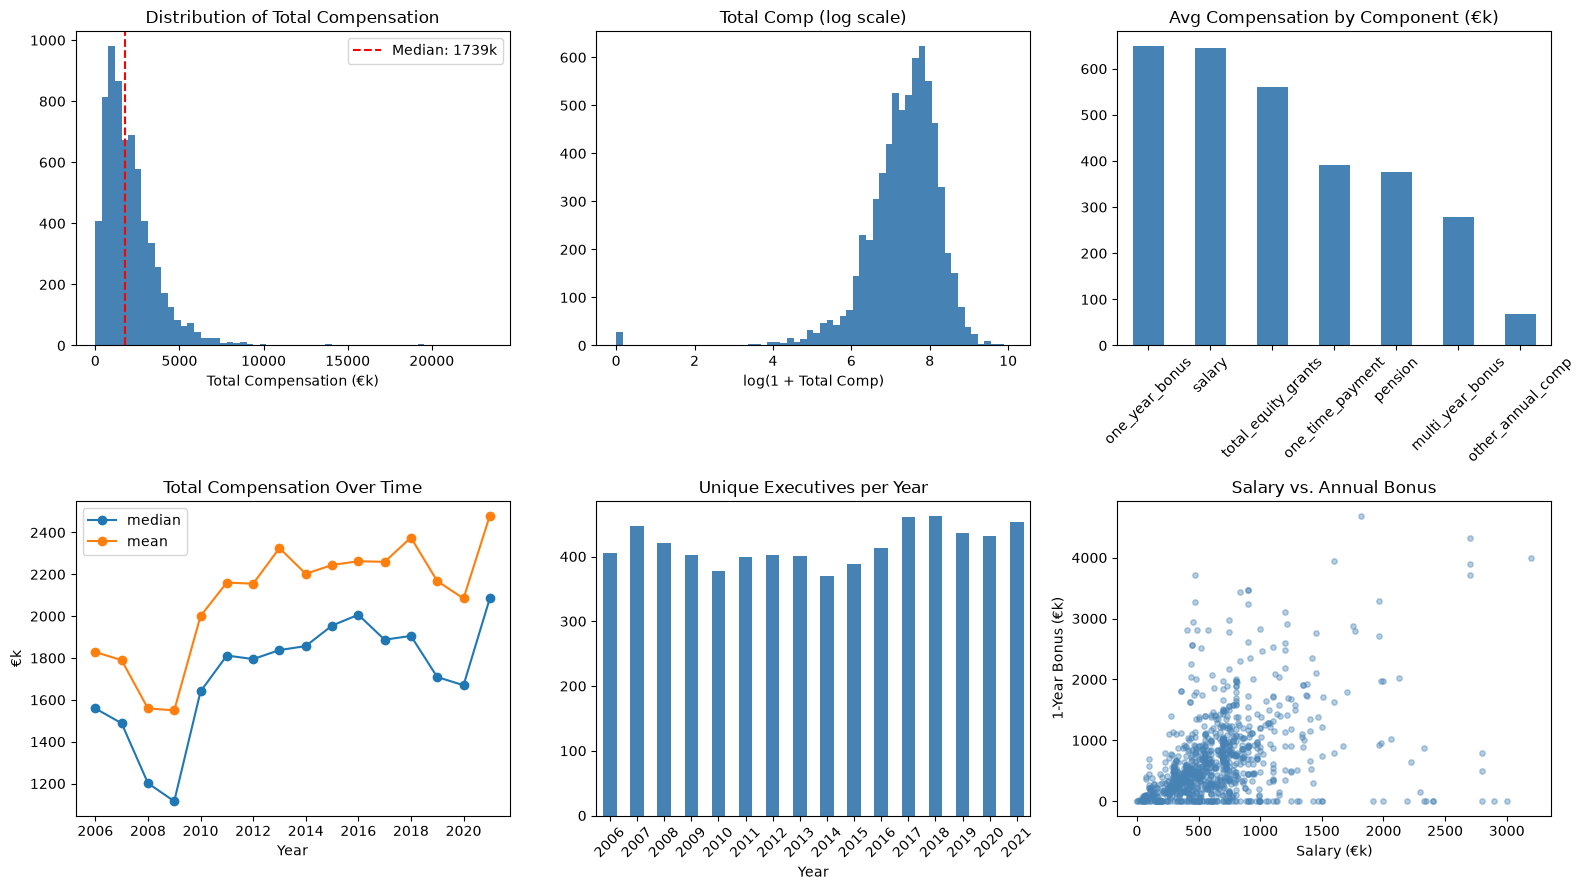

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# total compensation distribution (log scale)
ax = axes[0, 0]
valid = df['total_comp'].dropna()
ax.hist(valid, bins=60, color='steelblue', edgecolor='none')
ax.set_xlabel('Total Compensation (€k)')
ax.set_title('Distribution of Total Compensation')
ax.axvline(valid.median(), color='red', linestyle='--', label=f'Median: {valid.median():.0f}k')
ax.legend()

# log scale
ax = axes[0, 1]
ax.hist(np.log1p(valid), bins=60, color='steelblue', edgecolor='none')
ax.set_xlabel('log(1 + Total Comp)')
ax.set_title('Total Comp (log scale)')

# comp breakdown — average by component
ax = axes[0, 2]
avg_comp = df[['salary', 'one_year_bonus', 'multi_year_bonus',
               'total_equity_grants', 'other_annual_comp', 'pension',
               'one_time_payment']].mean().sort_values(ascending=False)
avg_comp.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Avg Compensation by Component (€k)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)

# total_comp over years (median and mean)
ax = axes[1, 0]
yearly = df.groupby('year')['total_comp'].agg(['median', 'mean'])
yearly.plot(ax=ax, marker='o')
ax.set_title('Total Compensation Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('€k')

# n_executives per year
ax = axes[1, 1]
df.groupby('year')['exec_id'].nunique().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Unique Executives per Year')
ax.set_xlabel('Year')
ax.tick_params(axis='x', rotation=45)

# salary vs bonus scatter
ax = axes[1, 2]
sample = df[['salary', 'one_year_bonus']].dropna().sample(min(1000, len(df)), random_state=42)
ax.scatter(sample['salary'], sample['one_year_bonus'], alpha=0.4, s=15, color='steelblue')
ax.set_xlabel('Salary (€k)')
ax.set_ylabel('1-Year Bonus (€k)')
ax.set_title('Salary vs. Annual Bonus')

plt.tight_layout()
plt.show()

In [61]:
top10_rows = df.nlargest(10, "total_comp")

top10_rows

,company_person_id,year,isin,company_shortname,company_name,exec_id,exec_fullname,days,ceo_flag_eoy,cfo_flag_eoy,date_begin_ceo,date_end_ceo,date_begin_cfo,date_end_cfo,salary,...,fy_begin,fy_end,salary_bt,one_year_bonus_bt,multi_year_bonus_bt,multi_year_bonus_grants_bt,multi_year_bonus_payout_bt,total_equity_grants_bt,stock_grants_bt,option_grants_bt,other_annual_bt,total_comp_bt,one_time_payment_bt,pension_bt,total_comp_pens_and_one_time_bt
948,1531.0,2018,DE0005200000,Beiersdorf,Beiersdorf AG,1453.0,Stefan Heidenreich,364.0,1.0,NaN,01jan2018,31dec2018,NaN,NaN,1250.000,...,01jan2018,31dec2018,4180.000,4201.000,25195.0,6948.0,25195.0,0.00,0.00,0.000,773.000,34349.00,0.0,0.000,34349.00
4387,1568.0,2021,DE0006483001,Linde,Linde plc,1489.0,Steve Angel,365.0,1.0,NaN,01jan2021,31dec2021,NaN,NaN,1341.174,...,01jan2021,31dec2021,3881.781,9741.317,0.0,0.0,0.0,24734.04,16842.50,7891.539,4943.860,43301.00,0.0,12064.120,55365.13
6708,198.0,2018,DE000ZAL1111,Zalando,Zalando SE,190.0,David Schneider,365.0,1.0,NaN,01jan2018,31dec2018,NaN,NaN,188.750,...,01jan2018,31dec2018,566.250,0.000,0.0,0.0,0.0,57453.05,0.00,57453.050,27.180,58046.48,0.0,0.000,58046.48
6710,1491.0,2018,DE000ZAL1111,Zalando,Zalando SE,1413.0,Rubin Ritter,365.0,1.0,1.0,01jan2018,31dec2018,01jan2018,31dec2018,188.750,...,01jan2018,31dec2018,566.250,0.000,0.0,0.0,0.0,57453.05,0.00,57453.050,27.180,58046.48,0.0,0.000,58046.48
6709,1467.0,2018,DE000ZAL1111,Zalando,Zalando SE,1389.0,Robert Gentz,365.0,1.0,NaN,01jan2018,31dec2018,NaN,NaN,188.750,...,01jan2018,31dec2018,566.250,0.000,0.0,0.0,0.0,57453.05,0.00,57453.050,27.180,58046.48,0.0,0.000,58046.48
6444,1387.0,2011,DE0007664005,Volkswagen,Volkswagen AG,1316.0,Prof. Dr. Martin Winterkorn,365.0,1.0,NaN,01jan2011,31dec2011,NaN,NaN,1886.000,...,01jan2011,31dec2011,9031.000,0.000,58320.0,NaN,NaN,0.00,0.00,0.000,0.000,67351.00,0.0,7945.505,75296.51
6471,1387.0,2014,DE0007664005,Volkswagen,Volkswagen AG,1316.0,Prof. Dr. Martin Winterkorn,365.0,1.0,NaN,01jan2014,31dec2014,NaN,NaN,1617.025,...,01jan2014,31dec2014,9791.987,10473.730,43692.5,42521.0,43692.5,0.00,0.00,0.000,1597.087,65555.30,0.0,4409.573,69964.88
6462,1387.0,2013,DE0007664005,Volkswagen,Volkswagen AG,1316.0,Prof. Dr. Martin Winterkorn,365.0,1.0,NaN,01jan2013,31dec2013,NaN,NaN,1907.862,...,01jan2013,31dec2013,11638.330,0.000,52444.3,NaN,NaN,0.00,0.00,0.000,0.000,64082.63,0.0,0.000,64082.63
6453,1387.0,2012,DE0007664005,Volkswagen,Volkswagen AG,1316.0,Prof. Dr. Martin Winterkorn,365.0,1.0,NaN,01jan2012,31dec2012,NaN,NaN,1916.276,...,01jan2012,31dec2012,9506.345,0.000,47000.0,NaN,NaN,0.00,0.00,0.000,0.000,56506.34,0.0,7870.299,64376.64
4382,1564.0,2020,DE0006483001,Linde,Linde plc,1485.0,Stephen Angel,365.0,1.0,NaN,01jan2020,31dec2020,NaN,NaN,1353.639,...,01jan2020,31dec2020,3912.303,6503.493,0.0,0.0,0.0,17600.89,12806.76,4794.131,1263.552,29280.24,0.0,5112.910,34393.15


### 2.3 CEO vs. CFO vs. Other Executive Pay

       n_obs  median_comp_k  mean_comp_k
role                                    
CEO     1269         2696.0       3283.2
CFO     1160         1477.8       1759.0
Other   4297         1570.0       1834.0



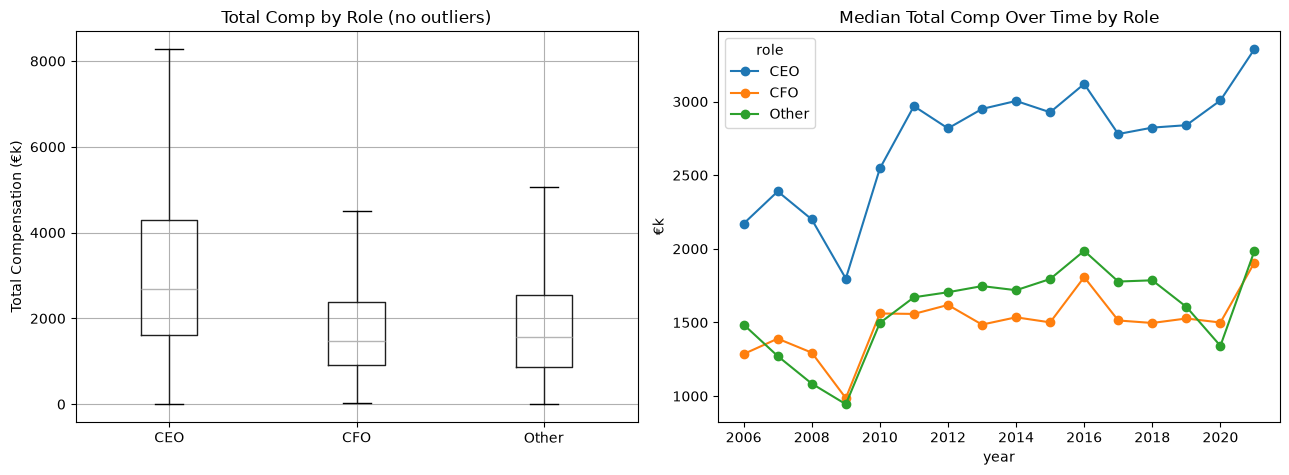

In [62]:
def role_label(row):
    if row['ceo_flag_eoy'] == 1:
        return 'CEO'
    elif row['cfo_flag_eoy'] == 1:
        return 'CFO'
    else:
        return 'Other'

df['role'] = df.apply(role_label, axis=1)

role_stats = df.groupby('role')['total_comp'].agg(['count', 'median', 'mean']).round(1)
role_stats.columns = ['n_obs', 'median_comp_k', 'mean_comp_k']
print(role_stats.to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# boxplot
df.boxplot(column='total_comp', by='role', ax=axes[0], showfliers=False)
axes[0].set_title('Total Comp by Role (no outliers)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Total Compensation (€k)')

# median over time by role
role_yearly = df.groupby(['year', 'role'])['total_comp'].median().unstack('role')
role_yearly.plot(ax=axes[1], marker='o')
axes[1].set_title('Median Total Comp Over Time by Role')
axes[1].set_ylabel('€k')

plt.suptitle('')
plt.tight_layout()
plt.show()

### 2.4 Gender Pay Gap

        n_obs  median_comp_k  mean_comp_k  share_%
gender                                            
Female    414         1803.2       1974.8      6.2
Male     6292         1736.6       2102.6     93.8



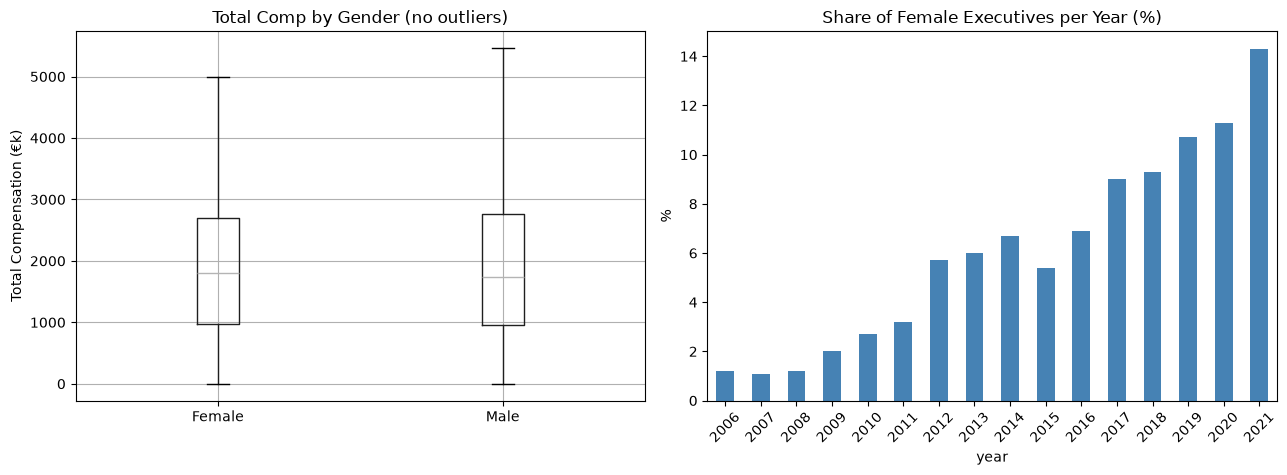

In [63]:
gender_map = {0: 'Male', 1: 'Female'}
df['gender'] = df['female'].map(gender_map)

gender_stats = df.groupby('gender')['total_comp'].agg(['count', 'median', 'mean']).round(1)
gender_stats.columns = ['n_obs', 'median_comp_k', 'mean_comp_k']
gender_share = df['gender'].value_counts(normalize=True).mul(100).round(1).rename('share_%')
print(pd.concat([gender_stats, gender_share], axis=1).to_string())
print()

# female share over time
female_by_year = (
    df.groupby('year')['female']
    .apply(lambda x: x.eq(1).sum() / x.notna().sum() * 100)
    .round(1)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df.boxplot(column='total_comp', by='gender', ax=axes[0], showfliers=False)
axes[0].set_title('Total Comp by Gender (no outliers)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Total Compensation (€k)')

female_by_year.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Share of Female Executives per Year (%)')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.show()

### 2.5 Index Listing (DAX, MDAX, SDAX…) & Company-Level Analysis

               n_obs  median_comp_k  mean_comp_k
index_listing                                   
DAX             3260         2541.5       2817.6
DAX and MDAX     232         1224.7       1536.4
MDAX            3019         1178.0       1424.7



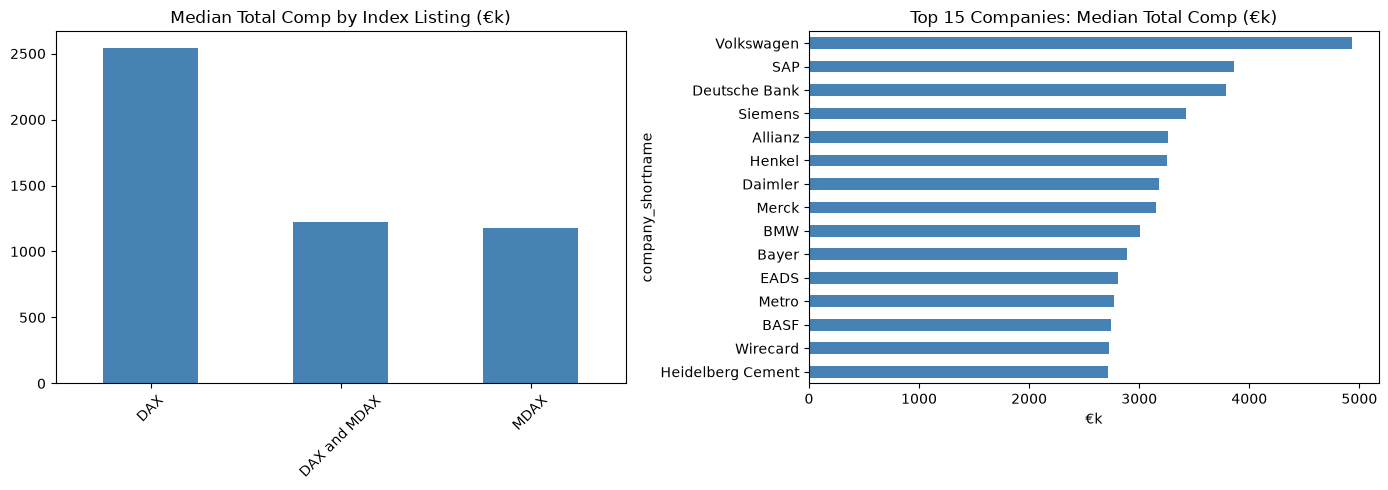

In [64]:
index_stats = (
    df.groupby('index_listing')['total_comp']
    .agg(['count', 'median', 'mean'])
    .round(1)
    .rename(columns={'count': 'n_obs', 'median': 'median_comp_k', 'mean': 'mean_comp_k'})
    .sort_values('median_comp_k', ascending=False)
)
print(index_stats.to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# median comp by index
index_stats['median_comp_k'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Median Total Comp by Index Listing (€k)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# top 15 companies by median total_comp
top_cos = (
    df.groupby('company_shortname')['total_comp']
    .median()
    .nlargest(15)
    .sort_values()
)
top_cos.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 Companies: Median Total Comp (€k)')
axes[1].set_xlabel('€k')

plt.tight_layout()
plt.show()

### 2.6 Nationality Breakdown

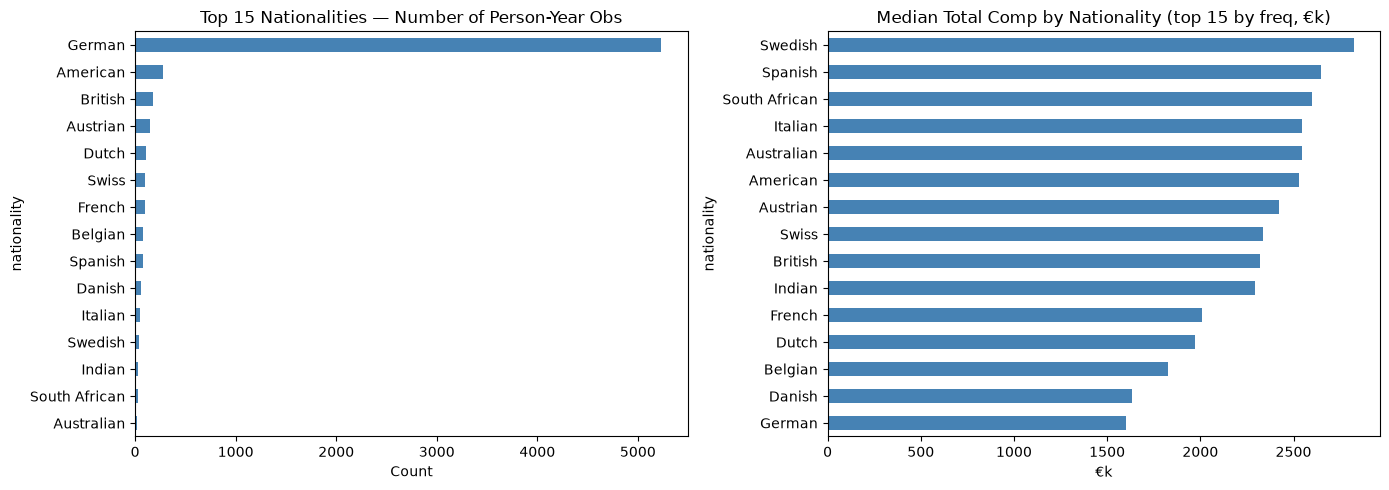


Top nationalities & median pay:
               n_obs  median_comp_k
nationality                        
German          5232         1598.0
American         278         2527.0
British          180         2322.0
Austrian         150         2423.0
Dutch            108         1971.0
Swiss            100         2337.0
French            97         2007.0
Spanish           75         2649.0
Belgian           75         1825.0
Danish            54         1633.0
Italian           47         2547.0
Swedish           43         2823.0
Indian            32         2296.0
South African     31         2598.0
Australian        23         2545.0


In [65]:
nat_counts = df['nationality'].value_counts().head(15)
nat_comp = (
    df.groupby('nationality')['total_comp']
    .median()
    .reindex(nat_counts.index)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nat_counts.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Nationalities — Number of Person-Year Obs')
axes[0].set_xlabel('Count')

nat_comp.sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Median Total Comp by Nationality (top 15 by freq, €k)')
axes[1].set_xlabel('€k')

plt.tight_layout()
plt.show()

print('\nTop nationalities & median pay:')
print(pd.DataFrame({'n_obs': nat_counts, 'median_comp_k': nat_comp.round(0)}).to_string())

### 2.7 Top Earners & Compensation Structure Correlation

Top 20 highest compensation records:
                  exec_fullname company_shortname  year   role  total_comp  total_comp_pens_and_one_time
0            Stefan Heidenreich        Beiersdorf  2018    CEO    23450.00                      23450.00
1                   Steve Angel             Linde  2021    CEO    19426.24                      26570.71
2               David Schneider           Zalando  2018    CEO    19351.30                      19351.30
3                  Rubin Ritter           Zalando  2018    CEO    19349.46                      19349.46
4                  Robert Gentz           Zalando  2018    CEO    19345.72                      19345.72
5   Prof. Dr. Martin Winterkorn        Volkswagen  2011    CEO    16596.00                      17471.00
6   Prof. Dr. Martin Winterkorn        Volkswagen  2014    CEO    15861.48                      15861.48
7   Prof. Dr. Martin Winterkorn        Volkswagen  2013    CEO    15005.86                      15005.86
8   Prof. Dr. Mart

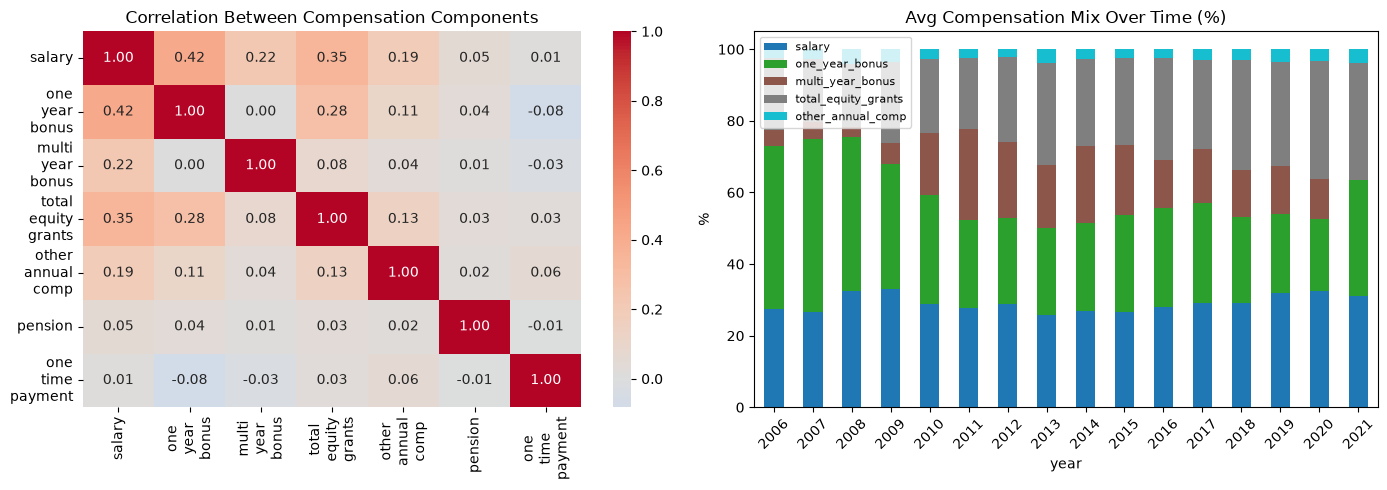

In [66]:
# Top 20 highest single-year payouts
top_earners = (
    df[['exec_fullname', 'company_shortname', 'year', 'role',
        'total_comp', 'total_comp_pens_and_one_time']]
    .dropna(subset=['total_comp'])
    .nlargest(20, 'total_comp')
    .reset_index(drop=True)
)
print('Top 20 highest compensation records:')
print(top_earners.to_string())
print()

# compensation component correlation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr_cols = ['salary', 'one_year_bonus', 'multi_year_bonus',
             'total_equity_grants', 'other_annual_comp', 'pension', 'one_time_payment']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0],
            xticklabels=[c.replace('_', '\n') for c in corr_cols],
            yticklabels=[c.replace('_', '\n') for c in corr_cols])
axes[0].set_title('Correlation Between Compensation Components')

# share of comp by component — stacked bar over years
comp_by_year = df.groupby('year')[['salary', 'one_year_bonus', 'multi_year_bonus',
                                    'total_equity_grants', 'other_annual_comp']].mean()
comp_by_year_pct = comp_by_year.div(comp_by_year.sum(axis=1), axis=0) * 100
comp_by_year_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10')
axes[1].set_title('Avg Compensation Mix Over Time (%)')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

### 2.8 Tenure & Board Duration Analysis

Executives with known board tenure: 4308
count    4308.0
mean        8.6
std         5.8
min         0.0
25%         4.3
50%         7.4
75%        11.5
max        52.5
Name: tenure_years, dtype: float64



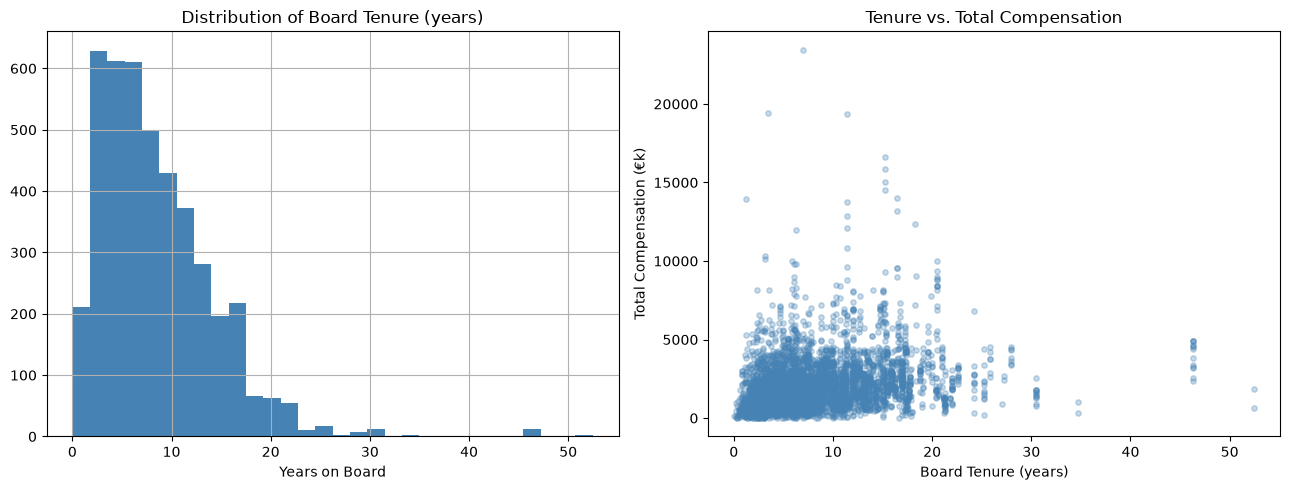

In [67]:
# Board tenure: years between board_entry_date and board_exit_date
def parse_stata_date(s):
    """Parse Stata-style dates like '01jan2008'."""
    try:
        return pd.to_datetime(s, format='%d%b%Y')
    except Exception:
        return pd.NaT

df['board_entry_dt'] = df['board_entry_date'].apply(parse_stata_date)
df['board_exit_dt'] = df['board_exit_date'].apply(parse_stata_date)
df['tenure_years'] = (df['board_exit_dt'] - df['board_entry_dt']).dt.days / 365.25

tenure_valid = df['tenure_years'].dropna()
print(f'Executives with known board tenure: {tenure_valid.count()}')
print(tenure_valid.describe().round(1))
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

tenure_valid.hist(bins=30, ax=axes[0], color='steelblue', edgecolor='none')
axes[0].set_title('Distribution of Board Tenure (years)')
axes[0].set_xlabel('Years on Board')

# tenure vs total_comp
t_c = df[['tenure_years', 'total_comp']].dropna()
axes[1].scatter(t_c['tenure_years'], t_c['total_comp'], alpha=0.3, s=15, color='steelblue')
axes[1].set_xlabel('Board Tenure (years)')
axes[1].set_ylabel('Total Compensation (€k)')
axes[1].set_title('Tenure vs. Total Compensation')

plt.tight_layout()
plt.show()

### 2.9 Save Merged Dataset

In [68]:
out_path = DATA / '2008-2020/merged_person_year_full.csv'
df.to_csv(out_path, index=False, sep='|')
print(f'Saved → {out_path}')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Saved → data\2008-2020\merged_person_year_full.csv
Shape: (6726, 66)
Columns: ['company_person_id', 'year', 'isin', 'company_shortname', 'company_name', 'exec_id', 'exec_fullname', 'days', 'ceo_flag_eoy', 'cfo_flag_eoy', 'date_begin_ceo', 'date_end_ceo', 'date_begin_cfo', 'date_end_cfo', 'salary', 'one_year_bonus', 'multi_year_bonus', 'multi_year_bonus_grants', 'multi_year_bonus_payout', 'total_equity_grants', 'stock_grants', 'option_grants', 'other_annual_comp', 'total_comp', 'pension', 'pension_missing', 'one_time_payment', 'total_comp_pens_and_one_time', 'exec_academic_title', 'exec_firstname', 'exec_lastname', 'female', 'nationality', 'date_of_birth', 'company_entry_date', 'board_entry_date', 'board_exit_date', 'board_entry_date_private', 'board_exit_date_private', 'company_entry_date2', 'board_entry_date2', 'opting_out', 'index_listing', 'new_cnameshort', 'n_executives', 'days_bt', 'fy_begin', 'fy_end', 'salary_bt', 'one_year_bonus_bt', 'multi_year_bonus_bt', 'multi_year_bonus_gra

## 2. Combining 2008–2020 and 2022–2024 Data

### 2a. cnameshort → ISIN Crosswalk

The 2022–2024 data identifies companies by short name only. We build a crosswalk from the 2008–2020 `company_year` table, then manually add the three new DAX entrants that don't appear there.

In [69]:
# build cnameshort → isin from 2008-2020 (take most recent entry per name to avoid stale ISINs)
crosswalk = (
    cy.sort_values('year', ascending=False)
    .drop_duplicates('company_shortname')[['company_shortname', 'isin']]
    .rename(columns={'company_shortname': 'cnameshort'})
)

# three DAX companies that joined after 2020
new_entrants = pd.DataFrame([
    {'cnameshort': 'Airbus',        'isin': 'NL0000235190'},
    {'cnameshort': 'Mercedes-Benz', 'isin': 'DE0007100000'},  # successor to Daimler AG
    {'cnameshort': 'Porsche',       'isin': 'DE000PAG9113'},  # Dr. Ing. h.c. F. Porsche AG (IPO 2022)
])
crosswalk = pd.concat([crosswalk, new_entrants], ignore_index=True)

print(f'Crosswalk entries: {len(crosswalk)}')
crosswalk.head(5)

Crosswalk entries: 166


,cnameshort,isin
0,Adidas,DE000A1EWWW0
1,Allianz,DE0008404005
2,Heidelberg Cement,DE0006047004
3,Porsche Automobil Holding,DE000PAH0038
4,Evonik,DE000EVNK013


### 2b. Load & Harmonize 2022–2024

**Column mapping to the 2008–2020 schema:**

| New (2022–2024) | Harmonized | Notes |
|---|---|---|
| `fix` | `salary` | base fixed pay |
| `sti` | `one_year_bonus` | short-term incentive (actual) |
| `mtiavg` | `multi_year_bonus` | medium-term incentive (average annual) |
| `lti` | `total_equity_grants` | long-term incentive (total grant value) |
| `ltishares` | `stock_grants` | shares component of LTI |
| `ltioption` | `option_grants` | options component of LTI |
| `others` (+`supplement` 2022) | `other_annual_comp` | other annual payments |
| `pension` | `pension` | pension contribution |
| `payoff` | `one_time_payment` | severance / one-off |
| `pgender` (m/f) | `female` (0/1) | |
| `pboardentry/exit` | `board_entry/exit_date` | already proper datetime |
| `pentryceoposition` | `date_begin_ceo` | |
| `Position` | `role` + `ceo/cfo_flag_eoy` | CEO→1, CFO→1 |

New columns (`fixgoal`, `stigoal`, `mtigoal`, `ltigoal`, KPI/governance cols) are kept as-is and will be `NaN` for 2008–2020 rows.

In [70]:
def load_sheet(filepath, sheet_name):
    raw = pd.read_excel(filepath, sheet_name=sheet_name, header=None)
    hdr_row = raw[raw.iloc[:, 0] == 'cnameshort'].index[0]
    return pd.read_excel(filepath, sheet_name=sheet_name, header=hdr_row)


def load_year(year, filepath, comp_sheet, members_sheet, companies_sheet):
    # ── Compensation ──────────────────────────────────────────────────────────
    comp = load_sheet(filepath, comp_sheet)
    comp = comp[[c for c in comp.columns if not str(c).startswith('Unnamed')]]

    # rename person keys first so they match mem join keys
    comp = comp.rename(columns={'pfirstname': 'exec_firstname', 'psurname': 'exec_lastname'})

    rename_comp = {
        'fix':       'salary',
        'sti':       'one_year_bonus',
        'mtiavg':    'multi_year_bonus',
        'lti':       'total_equity_grants',
        'ltishares': 'stock_grants',
        'ltioption': 'option_grants',
        'others':    'other_annual_comp',
        'payoff':    'one_time_payment',
    }
    comp = comp.rename(columns=rename_comp)

    # 2022 has 'supplement' (Konzernzulage) — fold into other_annual_comp
    if 'supplement' in comp.columns:
        comp['other_annual_comp'] = (
            comp.get('other_annual_comp', pd.Series(0, index=comp.index)).fillna(0)
            + comp['supplement'].fillna(0)
        )
        comp = comp.drop(columns=['supplement'])

    # computed totals (mirrors 2008-2020 definitions)
    pay_cols = ['salary', 'one_year_bonus', 'multi_year_bonus',
                'total_equity_grants', 'other_annual_comp']
    comp['total_comp'] = comp[pay_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1, min_count=1)
    comp['total_comp_pens_and_one_time'] = (
        comp['total_comp'].fillna(0)
        + comp.get('pension', pd.Series(0, index=comp.index)).fillna(0)
        + comp.get('one_time_payment', pd.Series(0, index=comp.index)).fillna(0)
    )

    comp['year'] = year
    comp['source'] = f'dsw_{year}'

    # ── Members ───────────────────────────────────────────────────────────────
    mem = load_sheet(filepath, members_sheet)
    mem = mem[[c for c in mem.columns if not str(c).startswith('Unnamed')]]

    mem = mem.rename(columns=lambda c: 'age' if c.startswith('Biologisches Alter') else c)

    rename_mem = {
        'pfirstname':        'exec_firstname',
        'psurname':          'exec_lastname',
        'ptitle':            'exec_academic_title',
        'pdob':              'date_of_birth',
        'pnationality':      'nationality',
        'pboardentry':       'board_entry_date',
        'pboardexit':        'board_exit_date',
        'pentryceoposition': 'date_begin_ceo',
        'TAGE im AMT':       'days',
    }
    mem = mem.rename(columns=rename_mem)

    mem['female'] = mem['pgender'].map({'m': 0, 'f': 1})
    mem = mem.drop(columns=['pgender'], errors='ignore')

    pos = mem.get('Position', pd.Series(dtype=str))
    mem['ceo_flag_eoy'] = pos.eq('CEO').astype(float).where(pos.notna())
    mem['cfo_flag_eoy'] = pos.eq('CFO').astype(float).where(pos.notna())
    mem['role'] = pos.apply(
        lambda x: ('CEO' if x == 'CEO' else 'CFO' if x == 'CFO' else 'Other')
        if pd.notna(x) else np.nan
    )
    mem['exec_fullname'] = (
        mem['exec_firstname'].fillna('') + ' ' + mem['exec_lastname'].fillna('')
    ).str.strip()

    # ── Companies (financial performance) ────────────────────────────────────
    raw_co = pd.read_excel(filepath, sheet_name=companies_sheet, header=None)
    hdr_row = raw_co[raw_co.iloc[:, 0].astype(str).str.startswith('cnameshort')].index[0]
    co = pd.read_excel(filepath, sheet_name=companies_sheet, header=hdr_row)
    co.columns = [
        str(c).split('(')[0].strip().lower()
         .replace(' ', '_').replace('ä', 'ae').replace('ö', 'oe')
         .replace('ü', 'ue').replace('ß', 'ss')
        if not str(c).startswith('Unnamed') else c
        for c in co.columns
    ]
    co = co.rename(columns={co.columns[0]: 'cnameshort'})
    co = co[[c for c in co.columns if not str(c).startswith('Unnamed')]]
    co = co.loc[:, ~co.columns.duplicated()]  # 2023 sheet has repeated column names
    co['year'] = year

    # ── Merge within year ─────────────────────────────────────────────────────
    JOIN_KEYS = ['cnameshort', 'exec_firstname', 'exec_lastname']

    mem_keep = mem[JOIN_KEYS + [
        'exec_fullname', 'exec_academic_title', 'date_of_birth', 'nationality',
        'board_entry_date', 'board_exit_date', 'date_begin_ceo',
        'days', 'female', 'ceo_flag_eoy', 'cfo_flag_eoy', 'role',
        'age', 'Position', 'Intern/Extern'
    ]]

    result = pd.merge(comp, mem_keep, on=JOIN_KEYS, how='left')
    result = pd.merge(result, co, on=['cnameshort', 'year'], how='left')
    result = pd.merge(result, crosswalk, on='cnameshort', how='left')
    result = result.rename(columns={'cnameshort': 'company_shortname'})

    # guard: drop any remaining duplicate columns before returning
    result = result.loc[:, ~result.columns.duplicated()]

    print(f'{year}: {result.shape[0]} rows, {result.shape[1]} cols | '
          f'isin matched: {result["isin"].notna().mean():.0%}')
    return result


FILES = {
    2022: ('data/2022/Executive_Compensation_2022.xlsx',
           'Compensation2022', 'Members2022', 'Companies2022'),
    2023: ('data/2023/Executive_Compensation_ 2023.xlsx',
           'Compensation2023', 'Members2023', 'Companies2023'),
    2024: ('data/2024/Executive_Compensation_2024.xlsx',
           'Compensation2024', 'Members2024', 'Companies2024'),
}

frames_new = []
for year, (filepath, cs, ms, cos) in FILES.items():
    frames_new.append(load_year(year, DATA / filepath[5:], cs, ms, cos))

df_new = pd.concat(frames_new, ignore_index=True)
print(f'\nCombined 2022-2024: {df_new.shape}')

2022: 258 rows, 108 cols | isin matched: 99%
2023: 265 rows, 102 cols | isin matched: 91%
2024: 256 rows, 98 cols | isin matched: 90%

Combined 2022-2024: (779, 118)


### 2c. Stack into one longitudinal dataset

In [71]:
# Align the 2008-2020 base with the new schema
# The `role` and `gender` columns were derived earlier; `exec_firstname/lastname` are in company_person.
# company_person had exec_firstname, exec_lastname already merged in via cp_slim.

# Make df columns consistent for stacking
df_base = df.copy()

# pfirstname / psurname exist in df_new but not df_base; exec_firstname / exec_lastname exist in df_base
# add them to df_new as aliases so concat aligns on exec_firstname/lastname
if 'pfirstname' in df_new.columns and 'exec_firstname' not in df_new.columns:
    df_new['exec_firstname'] = df_new['pfirstname']
if 'psurname' in df_new.columns and 'exec_lastname' not in df_new.columns:
    df_new['exec_lastname'] = df_new['psurname']

# Stack — pd.concat fills missing columns with NaN automatically
df_long = pd.concat([df_base, df_new], ignore_index=True, sort=False)

# ensure year is int
df_long['year'] = df_long['year'].astype(int)

print(f'Full longitudinal dataset: {df_long.shape}')
print(f'Years: {sorted(df_long["year"].unique())}')
print(f'Unique companies: {df_long["company_shortname"].nunique()}')
print(f'Unique executives (by name): {df_long["exec_fullname"].nunique()}')
print()
print('Rows per source:')
print(df_long['source'].value_counts())

Full longitudinal dataset: (7505, 156)
Years: [np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Unique companies: 162
Unique executives (by name): 1613

Rows per source:
source
dsw_2023    265
dsw_2022    258
dsw_2024    256
Name: count, dtype: int64


### 2d. Validation & Column Coverage

In [72]:
# For each core column, show fill rate by source period
core_cols = ['salary', 'one_year_bonus', 'multi_year_bonus', 'total_equity_grants',
             'stock_grants', 'option_grants', 'other_annual_comp', 'pension',
             'one_time_payment', 'total_comp', 'total_comp_pens_and_one_time',
             'female', 'nationality', 'date_of_birth', 'board_entry_date', 'board_exit_date',
             'ceo_flag_eoy', 'cfo_flag_eoy', 'role', 'isin']

df_long['period'] = np.where(df_long['year'] <= 2020, '2008-2020', '2022-2024')
fill_rate = (
    df_long.groupby('period')[core_cols]
    .apply(lambda g: g.notna().mean() * 100)
    .round(1)
    .T
)
fill_rate.columns.name = 'fill_rate_%'
print('Core column fill rates by period (%):')
print(fill_rate.to_string())

# also check new governance columns that only exist in 2022-2024
new_cols = [c for c in df_long.columns
            if c not in df_base.columns and not str(c).startswith('Unnamed')]
print(f'\nNew columns only in 2022–2024 ({len(new_cols)}):')
print(new_cols)

Core column fill rates by period (%):
fill_rate_%                   2008-2020  2022-2024
salary                             99.9       99.4
one_year_bonus                     95.4       99.4
multi_year_bonus                   83.6       99.4
total_equity_grants                93.6       98.5
stock_grants                       81.9       88.3
option_grants                      53.3        5.4
other_annual_comp                  99.9       99.6
pension                            83.3       98.1
one_time_payment                   49.3       69.3
total_comp                        100.0       99.6
total_comp_pens_and_one_time      100.0      100.0
female                             99.7       99.4
nationality                        99.3       99.4
date_of_birth                      99.5       99.3
board_entry_date                   99.7       99.4
board_exit_date                    67.8       11.3
ceo_flag_eoy                       18.8       60.3
cfo_flag_eoy                       18.2     

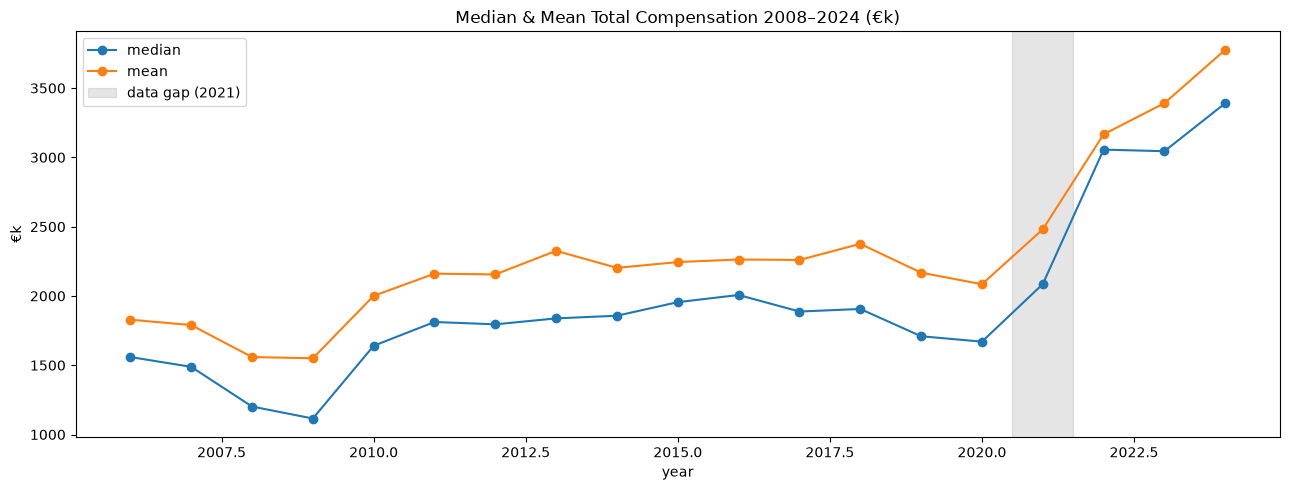


Observations per year:
year  period   
2006  2008-2020    407
2007  2008-2020    450
2008  2008-2020    423
2009  2008-2020    404
2010  2008-2020    378
2011  2008-2020    405
2012  2008-2020    405
2013  2008-2020    407
2014  2008-2020    372
2015  2008-2020    391
2016  2008-2020    421
2017  2008-2020    471
2018  2008-2020    465
2019  2008-2020    438
2020  2008-2020    433
2021  2022-2024    456
2022  2022-2024    255
2023  2022-2024    262
2024  2022-2024    254


In [73]:
# Quick sanity check: median total_comp over full time range
fig, ax = plt.subplots(figsize=(13, 5))
yearly = df_long.groupby('year')['total_comp'].agg(['median', 'mean'])
yearly.plot(ax=ax, marker='o')
ax.axvspan(2020.5, 2021.5, color='grey', alpha=0.2, label='data gap (2021)')
ax.set_title('Median & Mean Total Compensation 2008–2024 (€k)')
ax.set_ylabel('€k')
ax.legend()
plt.tight_layout()
plt.show()

print('\nObservations per year:')
print(df_long.groupby(['year', 'period'])['exec_fullname'].count().to_string())

In [74]:
# Save the full longitudinal dataset
out_path_long = DATA / '2008-2024_longitudinal.csv'
df_long.to_csv(out_path_long, index=False, sep='|')
print(f'Saved → {out_path_long}')
print(f'Shape: {df_long.shape}')

Saved → data\2008-2024_longitudinal.csv
Shape: (7505, 157)


## 3 Data Dictionary — `df_long` (2008–2024 longitudinal dataset)

All monetary values are in **€ thousands (€k)**. Columns marked **(2008–2020 only)** are `NaN` for 2022–2024 rows; columns marked **(2022–2024 only)** are `NaN` for 2008–2020 rows.

---

### Identifiers & Metadata

| Column | Description | Source |
|---|---|---|
| `isin` | International Securities Identification Number of the company | Derived via cnameshort → ISIN crosswalk |
| `company_shortname` | Short company name; primary company key across both periods | Both periods |
| `company_name` | Full legal company name | 2008–2020 only |
| `company_person_id` | Numeric ID for a unique person–company relationship | 2008–2020 only |
| `exec_id` | Numeric executive ID, unique per person in the academic dataset | 2008–2020 only |
| `year` | Fiscal/reporting year | Both periods |
| `source` | Dataset origin: `academic_2008-2020`, `dsw_2022`, `dsw_2023`, or `dsw_2024` | Both periods |
| `period` | Coarse period label: `'2008-2020'` or `'2022-2024'` | Derived |

---

### Executive Demographics

| Column | Description | Source |
|---|---|---|
| `exec_firstname` | First name | Both periods |
| `exec_lastname` | Last name | Both periods |
| `exec_fullname` | First + last name concatenated | Both periods |
| `exec_academic_title` | Academic title (e.g. Dr., Prof. Dr.) | Both periods |
| `female` | Gender flag: 0 = male, 1 = female | Both periods |
| `gender` | Human-readable gender: `'Male'` or `'Female'` (derived from `female`) | Derived |
| `nationality` | Nationality as text. **Note:** 2008–2020 uses English ("German"), 2022–2024 uses German ("Deutsch") — not directly comparable without normalisation | Both periods |
| `date_of_birth` | Date of birth. Stata-style string in 2008–2020 (`01jan1965`); ISO datetime in 2022–2024 | Both periods |
| `age` | Executive age at 31 Dec of the reporting year | 2022–2024 only |

---

### Board Membership & Role

| Column | Description | Source |
|---|---|---|
| `days` | Days the executive was on the management board during the fiscal year (365 = full year) | Both periods |
| `ceo_flag_eoy` | 1 if the executive held the CEO position at end of year, else NaN | Both periods |
| `cfo_flag_eoy` | 1 if the executive held the CFO position at end of year, else NaN | Both periods |
| `role` | Derived role label: `'CEO'`, `'CFO'`, or `'Other'` | Derived |
| `Position` | Exact position title as recorded (CEO, CFO, CHRO, COO, CTO, etc.) | 2022–2024 only |
| `Intern/Extern` | Whether the executive was internally promoted or externally recruited | 2022–2024 only |
| `board_entry_date` | Date the executive joined the management board | Both periods |
| `board_exit_date` | Date the executive left the board (NaN if still active at data cut-off) | Both periods |
| `board_entry_dt` / `board_exit_dt` | Board entry / exit dates parsed as Python datetime objects | Derived (2008–2020) |
| `tenure_years` | Total board tenure in fractional years (`board_exit_dt − board_entry_dt`) | Derived (2008–2020) |
| `date_begin_ceo` | Date the executive first became CEO at this company | Both periods |
| `date_end_ceo` | Date the executive stepped down as CEO | 2008–2020 only |
| `date_begin_cfo` / `date_end_cfo` | CFO role start / end dates | 2008–2020 only |
| `company_entry_date` | Date the executive first joined the company (may predate board entry) | 2008–2020 only |
| `board_entry_date_private` / `board_exit_date_private` | Alternative board entry/exit dates from a private source (rarely populated) | 2008–2020 only |
| `company_entry_date2` / `board_entry_date2` | Second entry dates for executives who rejoined after a break (rarely populated) | 2008–2020 only |

---

### Individual Compensation Components

These are the **individual executive's** compensation amounts for the fiscal year.

| Column | Description | Source |
|---|---|---|
| `salary` | Fixed base salary (€k). In dsw data this is `fix` | Both periods |
| `one_year_bonus` | Short-term incentive / annual variable bonus actually received (€k). In dsw data this is `sti` | Both periods |
| `multi_year_bonus` | Multi-year / medium-term incentive (€k). In 2008–2020: actual MTI payment in that year; in 2022–2024: `mtiavg`, the average annual payout over the MTI plan period. **Concepts are similar but not identical.** | Both periods |
| `multi_year_bonus_grants` | Value of multi-year bonus **granted** this year (€k) — the promise, not the payout | 2008–2020 only |
| `multi_year_bonus_payout` | Value of multi-year bonus **paid out** this year (€k) — cash actually received | 2008–2020 only |
| `total_equity_grants` | Total fair value of equity-based LTI grants: shares + options (€k). Mapped from `lti` | Both periods |
| `stock_grants` | Fair value of share/stock grants within LTI (€k). Mapped from `ltishares` | Both periods |
| `option_grants` | Fair value of stock option grants within LTI (€k). Mapped from `ltioption` | Both periods |
| `other_annual_comp` | Other annual payments: company car, insurance, allowances, etc. (€k). In 2022 also includes `supplement` (Konzernzulage = group-level supplement) | Both periods |
| `pension` | Employer pension contribution or defined-benefit service cost allocated to this executive (€k) | Both periods |
| `pension_missing` | 1 = pension was not disclosed, so the 0 in `pension` is a structural zero, not a true zero | 2008–2020 only |
| `one_time_payment` | One-off or severance payments outside the regular remuneration structure (€k). Mapped from `payoff` | Both periods |
| `hochrechnung_periode` | Pro-rata extrapolation factor for executives on the board less than a full year (e.g. 0.5 = six months active) | 2022–2024 only |

---

### Individual Compensation Totals (Derived)

| Column | Formula | Description |
|---|---|---|
| `total_comp` | salary + one_year_bonus + multi_year_bonus + total_equity_grants + other_annual_comp | Core total compensation (€k); excludes pension and one-time payments |
| `total_comp_pens_and_one_time` | total_comp + pension + one_time_payment | Broadest compensation measure including all cash flows to the executive (€k) |

---

### Board-Level Compensation Totals (`_bt` columns) — 2008–2020 only

Each `_bt` column is the **aggregate across all executives** on the management board for that company-year. They originate from `company_year.csv` (one record per company-year) and are **broadcast to every person-year row** via a left join on `isin + year`. All `_bt` values are therefore identical for every executive at the same company in the same year.

| Column | Description |
|---|---|
| `salary_bt` | Total board salary (€k) |
| `one_year_bonus_bt` | Total board one-year bonus (€k) |
| `multi_year_bonus_bt` | Total board multi-year bonus (€k) |
| `multi_year_bonus_grants_bt` | Total board multi-year bonus grants (€k) |
| `multi_year_bonus_payout_bt` | Total board multi-year bonus payouts (€k) |
| `total_equity_grants_bt` | Total board equity grants (€k) |
| `stock_grants_bt` | Total board stock grants (€k) |
| `option_grants_bt` | Total board option grants (€k) |
| `other_annual_bt` | Total board other annual compensation (€k) |
| `total_comp_bt` | Total board compensation — sum of all executives' `total_comp` (€k) |
| `one_time_payment_bt` | Total board one-time payments (€k) |
| `pension_bt` | Total board pension contributions (€k) |
| `total_comp_pens_and_one_time_bt` | Total board compensation incl. pension and one-time (€k) |
| `n_executives` | Number of executives on the management board that year |
| `days_bt` | Sum of board-days across all executives (e.g. 3 full-year members = 1095) |
| `fy_begin` / `fy_end` | Fiscal year start / end date (relevant for non-calendar fiscal years) |
| `opting_out` | 1 if the company opted out of the voluntary German compensation disclosure system in this year |
| `index_listing` | Stock index membership at year-end: DAX, MDAX, SDAX, TecDAX, or NaN |
| `new_cnameshort` | Updated company short name if the company was renamed after this reporting year |

---

### Incentive Structure & KPI Governance — 2022–2024 only

These columns describe **how** compensation is designed, not just the amounts. Prefix convention: `sti` = short-term incentive (annual bonus), `mti` = medium-term incentive (2–4 year plan), `lti` = long-term incentive (equity-based, 4+ years).

| Column | Description |
|---|---|
| `fixgoal` | Fixed salary as % of total **target** compensation (illustrates intended pay mix) |
| `stigoal` | STI target payout as % of total target compensation |
| `sticomment` | Free-text description of the STI plan mechanics |
| `stipiquantity` | Number of distinct KPIs in the STI plan |
| `stipi1` / `stipi2` / `stipi3` | Name of the 1st / 2nd / 3rd STI performance indicator (e.g. "EBIT", "Revenue growth") |
| `stipi1weight` / `stipi2weight` / `stipi3weight` | Weight of each KPI in the STI payout (%) |
| `stirpe1` / `stirpe2` / `stirpe3` | Relative Performance Evaluation flag: 1 = this KPI is benchmarked against a peer group |
| `stipinf` | 1 if the STI includes at least one non-financial KPI (ESG, employee satisfaction, etc.) |
| `stipiacc` | 1 if the STI includes accounting/financial KPIs (EBIT, FCF, etc.) |
| `stipicm` | 1 if the STI includes capital-market KPIs (TSR, share price, etc.) |
| `sticapdummy` | 1 if the STI payout has a defined maximum cap |
| `sticap` / `sticaprel` | STI cap in absolute €k / as % of STI target |
| `mtigoal` | MTI target as % of total target compensation |
| `mtiyears` | Duration of the MTI plan in years |
| `mtipiquantity` | Number of KPIs in the MTI plan |
| `mtipi1` / `mtipi2` / `mtipi3` | Names of MTI performance indicators |
| `mtipinf` / `mtipiacc` / `mtipicm` | MTI KPI type flags (non-financial / accounting / capital-market) |
| `mticapdummy` | 1 if the MTI payout has a maximum cap |
| `ltigoal` | LTI target as % of total target compensation |
| `ltiperiodshares` / `ltiperiodoption` | Vesting period for share grants / option grants (years) |
| `ltisystem` | LTI instrument type (performance shares, phantom shares, stock options, etc.) |
| `ltiperfdummy` | 1 if LTI vesting is contingent on performance targets |
| `ltipiquantity` | Number of KPIs governing LTI vesting |
| `ltipi1` / `ltipi2` | Names of LTI performance indicators |
| `ltipinf` / `ltipiacc` / `ltipicm` | LTI KPI type flags |
| `lticapdummy` | 1 if the LTI payout has a maximum cap |

---

### Company Financial Performance — 2022–2024 only

From the `CompaniesYYYY` sheet. Company-level metrics broadcast to all executive rows for the same company-year.

| Column | Description |
|---|---|
| `eps_veraenderung_` | Year-over-year % change in Earnings Per Share |
| `shareholder_return_` | Total Shareholder Return (price appreciation + dividends) for the fiscal year |
| `tsr` | Total Shareholder Return (may overlap with above depending on year) |
| `dividende_pro_aktie` | Dividend per share paid in the fiscal year (€) |
| `earnings_per_share_` | Earnings Per Share for the reporting year (€) |


## 4 Debugging / Exploration

In [75]:
# 1) Column (feature) names
cols = df_long.columns.tolist()
cols

['company_person_id',
 'year',
 'isin',
 'company_shortname',
 'company_name',
 'exec_id',
 'exec_fullname',
 'days',
 'ceo_flag_eoy',
 'cfo_flag_eoy',
 'date_begin_ceo',
 'date_end_ceo',
 'date_begin_cfo',
 'date_end_cfo',
 'salary',
 'one_year_bonus',
 'multi_year_bonus',
 'multi_year_bonus_grants',
 'multi_year_bonus_payout',
 'total_equity_grants',
 'stock_grants',
 'option_grants',
 'other_annual_comp',
 'total_comp',
 'pension',
 'pension_missing',
 'one_time_payment',
 'total_comp_pens_and_one_time',
 'exec_academic_title',
 'exec_firstname',
 'exec_lastname',
 'female',
 'nationality',
 'date_of_birth',
 'company_entry_date',
 'board_entry_date',
 'board_exit_date',
 'board_entry_date_private',
 'board_exit_date_private',
 'company_entry_date2',
 'board_entry_date2',
 'opting_out',
 'index_listing',
 'new_cnameshort',
 'n_executives',
 'days_bt',
 'fy_begin',
 'fy_end',
 'salary_bt',
 'one_year_bonus_bt',
 'multi_year_bonus_bt',
 'multi_year_bonus_grants_bt',
 'multi_year_bonus

In [76]:
# 2) Column names + dtypes
df_long.dtypes

company_person_id           float64
year                          int64
isin                            str
company_shortname               str
company_name                    str
                             ...   
tsr.1                       float64
dividende_pro_aktie_gj24    float64
kurs_31.12.24               float64
dividende_veraenderung      float64
period                          str
Length: 157, dtype: object

In [77]:
# Jupyter-friendly snippet (no dataframe modification)

cols = df_long.columns.tolist()
S = set(cols)

# --- 1) Exact same aspect via _bt (main vs back/benchmark counterpart) ---
def strip_suffix(c):
    return c.lower().replace("_bt", "")

dupes_bt = {}
for c in cols:
    if c.endswith("_bt"):
        counterpart = c.replace("_bt", "")
    else:
        counterpart = c + "_bt"
    if counterpart in S:
        dupes_bt[c] = counterpart

pairs_bt = sorted({tuple(sorted((a, b))) for a, b in dupes_bt.items()})

print("Pairs differing only by _bt:")
for a, b in pairs_bt:
    print(f"  {a} <-> {b}")

# --- 2) Near-duplicates by name "stem" (useful for stipi1/2/3, mtirpe1/2/3, etc.) ---
import re
from collections import defaultdict

def stem(c):
    c = c.lower().replace("_bt", "")
    c = re.sub(r'(stipi|stirpe|mtipi|mtirpe|ltipi|ltirpe)\d+$', r'\1', c)
    c = re.sub(r'\d+$', '', c)
    return c

groups = defaultdict(list)
for c in cols:
    groups[stem(c)].append(c)

near_dupe_groups = {k: v for k, v in groups.items() if len(v) >= 2}

print("\nNear-duplicate groups by name stem (candidates):")
for k, v in sorted(near_dupe_groups.items(), key=lambda x: (-len(x[1]), x[0])):
    print(f"  {k}: {v}")


Pairs differing only by _bt:
  days <-> days_bt
  multi_year_bonus <-> multi_year_bonus_bt
  multi_year_bonus_grants <-> multi_year_bonus_grants_bt
  multi_year_bonus_payout <-> multi_year_bonus_payout_bt
  one_time_payment <-> one_time_payment_bt
  one_year_bonus <-> one_year_bonus_bt
  option_grants <-> option_grants_bt
  pension <-> pension_bt
  salary <-> salary_bt
  stock_grants <-> stock_grants_bt
  total_comp <-> total_comp_bt
  total_comp_pens_and_one_time <-> total_comp_pens_and_one_time_bt
  total_equity_grants <-> total_equity_grants_bt

Near-duplicate groups by name stem (candidates):
  kurs_31.12.: ['kurs_31.12.23', 'kurs_31.12.22', 'kurs_31.12.24']
  mtipi: ['mtipi1', 'mtipi2', 'mtipi3']
  mtirpe: ['mtirpe1', 'mtirpe2', 'mtirpe3']
  stipi: ['stipi1', 'stipi2', 'stipi3']
  stirpe: ['stirpe1', 'stirpe2', 'stirpe3']
  aktienkurs_31.12.: ['aktienkurs_31.12.22', 'aktienkurs_31.12.21']
  board_entry_date: ['board_entry_date', 'board_entry_date2']
  company_entry_date: ['company

In [78]:
cols = df_long.columns.tolist()
S = set(cols)

def values_problem(a, b):
    s1, s2 = df_long[a], df_long[b]

    # mask where at least one side is non-NaN
    m = ~(s1.isna() & s2.isna())

    # within that mask, it's a problem if the non-NaN values differ
    # (NaN vs non-NaN will also be flagged as problem, as desired)
    return (s1[m].ne(s2[m])).any()

# candidate pairs: differ only by _bt
pairs = []
for c in cols:
    counterpart = c.replace("_bt", "") if c.endswith("_bt") else (c + "_bt")
    if counterpart in S and c <= counterpart:
        pairs.append((c, counterpart))

print(f"Checking {len(pairs)} candidate _bt pairs...")

problems = []
for a, b in pairs:
    if values_problem(a, b):
        problems.append((a, b))

print("\nPairs with non-NaN differing values (problem):")
for a, b in problems:
    print(f"  {a} <-> {b}")

print(f"\nTotal problem pairs: {len(problems)}")


Checking 13 candidate _bt pairs...

Pairs with non-NaN differing values (problem):
  days <-> days_bt
  salary <-> salary_bt
  one_year_bonus <-> one_year_bonus_bt
  multi_year_bonus <-> multi_year_bonus_bt
  multi_year_bonus_grants <-> multi_year_bonus_grants_bt
  multi_year_bonus_payout <-> multi_year_bonus_payout_bt
  total_equity_grants <-> total_equity_grants_bt
  stock_grants <-> stock_grants_bt
  option_grants <-> option_grants_bt
  total_comp <-> total_comp_bt
  pension <-> pension_bt
  one_time_payment <-> one_time_payment_bt
  total_comp_pens_and_one_time <-> total_comp_pens_and_one_time_bt

Total problem pairs: 13


In [79]:
cols = df_long.columns.tolist()
S = set(cols)

def mismatch_examples(a, b, n=10):
    s1, s2 = df_long[a], df_long[b]
    m = ~(s1.isna() & s2.isna())          # ignore rows where both are NaN
    bad = m & s1.ne(s2)                   # rows with problem (includes NaN vs non-NaN, or differing non-NaN)
    idx = df_long.index[bad]

    examples = []
    for i in idx[:n]:
        examples.append({
            "index": i,
            a: s1.loc[i],
            b: s2.loc[i],
        })
    return examples

# candidate pairs: differ only by _bt
pairs = []
for c in cols:
    counterpart = c.replace("_bt", "") if c.endswith("_bt") else (c + "_bt")
    if counterpart in S and c <= counterpart:
        pairs.append((c, counterpart))

# show examples for the first few problematic pairs
shown = 0
for a, b in pairs:
    # if there is any mismatch, print examples
    ex = mismatch_examples(a, b, n=10)
    if ex:
        print(f"\nPROBLEM PAIR: {a} <-> {b} (showing {len(ex)} examples)")
        for e in ex:
            print(e)
        shown += 1
        if shown >= 5:   # adjust how many pairs you want to inspect
            break

print(f"\nChecked {len(pairs)} candidate pairs; showing up to 5 problematic pairs above.")



PROBLEM PAIR: days <-> days_bt (showing 10 examples)
{'index': 0, 'days': np.float64(365.0), 'days_bt': np.float64(820.0)}
{'index': 1, 'days': np.float64(91.0), 'days_bt': np.float64(820.0)}
{'index': 2, 'days': np.float64(364.0), 'days_bt': np.float64(820.0)}
{'index': 3, 'days': np.float64(365.0), 'days_bt': np.float64(730.0)}
{'index': 4, 'days': np.float64(365.0), 'days_bt': np.float64(730.0)}
{'index': 5, 'days': np.float64(365.0), 'days_bt': np.float64(1111.0)}
{'index': 6, 'days': np.float64(121.0), 'days_bt': np.float64(1111.0)}
{'index': 7, 'days': np.float64(260.0), 'days_bt': np.float64(1111.0)}
{'index': 8, 'days': np.float64(365.0), 'days_bt': np.float64(1111.0)}
{'index': 9, 'days': np.float64(365.0), 'days_bt': np.float64(1017.0)}

PROBLEM PAIR: salary <-> salary_bt (showing 10 examples)
{'index': 0, 'salary': np.float64(400.0), 'salary_bt': np.float64(1400.0)}
{'index': 1, 'salary': np.float64(300.0), 'salary_bt': np.float64(1400.0)}
{'index': 2, 'salary': np.float64(

In [81]:
# 1) Show all columns (wider output)
pd.set_option('display.max_columns', None)

# 2) Optional: show full cell contents
pd.set_option('display.max_colwidth', None)

# 3) Optional: show more rows (otherwise it still truncates)
pd.set_option('display.max_rows', 200)

# 4) Now display
df_long.head()


,company_person_id,year,isin,company_shortname,company_name,exec_id,exec_fullname,days,ceo_flag_eoy,cfo_flag_eoy,date_begin_ceo,date_end_ceo,date_begin_cfo,date_end_cfo,salary,one_year_bonus,multi_year_bonus,multi_year_bonus_grants,multi_year_bonus_payout,total_equity_grants,stock_grants,option_grants,other_annual_comp,total_comp,pension,pension_missing,one_time_payment,total_comp_pens_and_one_time,exec_academic_title,exec_firstname,exec_lastname,female,nationality,date_of_birth,company_entry_date,board_entry_date,board_exit_date,board_entry_date_private,board_exit_date_private,company_entry_date2,board_entry_date2,opting_out,index_listing,new_cnameshort,n_executives,days_bt,fy_begin,fy_end,salary_bt,one_year_bonus_bt,multi_year_bonus_bt,multi_year_bonus_grants_bt,multi_year_bonus_payout_bt,total_equity_grants_bt,stock_grants_bt,option_grants_bt,other_annual_bt,total_comp_bt,one_time_payment_bt,pension_bt,total_comp_pens_and_one_time_bt,role,gender,board_entry_dt,board_exit_dt,tenure_years,fixgoal,stigoal,sticomment,stipiquantity,stipi1,stipi1weight,stirpe1,stipi2,stipi2weight,stirpe2,stipi3,stipi3weight,stirpe3,stipinf,stipiacc,stipicm,sticapdummy,sticap,sticaprel,mtiprov,mtiadj,mtigoal,mticomment,mtiori,mtiyears,mtipiquantity,mtipi1,mtipi1weight,mtirpe1,mtipi2,mtipi2weight,mtirpe2,mtipi3,mtipi3weight,mtirpe3,mtipinf,mtipiacc,mtipicm,mtitransfer,mtisystem,mticapdummy,mticapearn,mticapreal,mticaprel,ltigoal,lticomment,ltipay,ltiperiodshares,ltiperiodoption,ltisystem,ltiperfdummy,ltiperftarget,ltipiquantity,ltipi1,ltipi1weight,ltirpe1,ltipi2,ltipi2weight,ltirpe2,ltipinf,ltipiacc,ltipicm,ltitransfer,lticapdummy,lticapearn,lticapreal,lticaprel,hochrechnung periode,source,age,Position,Intern/Extern,eps_veraenderung,shareholder_return,dividende_pro_aktie,earnings_per_share,aktienkurs_31.12.22,aktienkurs_31.12.21,dividende_22,tsr,kurs_31.12.23,kurs_31.12.22,dividende_gj23,kurs_31.12.23.1,kurs_31.12.22.1,dividende_gj23.1,tsr.1,dividende_pro_aktie_gj24,kurs_31.12.24,dividende_veraenderung,period
0,56.0,2017,DE0005545503,1&1 Drillisch,1&1 Drillisch AG,53.0,André Driesen,365.0,NaN,1.0,NaN,NaN,01jan2017,31dec2017,400.0,350.0,0.0,100.0,0.0,0.0,0.0,0.0,12.0,762.0,1.0,0.0,NaN,763.0,NaN,André,Driesen,0.0,German,01jan1969,01jan2003,01apr2015,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,3.0,820.0,01jan2017,31dec2017,1400.0,1450.0,0.0,1662.0,0.0,0.0,0.0,0.0,45.0,2895.0,1907.0,2.0,4804.0,CFO,Male,2015-04-01,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-2020
1,1198.0,2017,DE0005545503,1&1 Drillisch,1&1 Drillisch AG,1138.0,Martin Witt,91.0,NaN,NaN,NaN,NaN,NaN,NaN,300.0,200.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,513.0,0.0,0.0,NaN,513.0,NaN,Martin,Witt,0.0,German,01jan1955,01oct2017,01oct2017,NaN,01apr2019,01oct2017,NaN,NaN,0.0,NaN,NaN,3.0,820.0,01jan2017,31dec2017,1400.0,1450.0,0.0,1662.0,0.0,0.0,0.0,0.0,45.0,2895.0,1907.0,2.0,4804.0,Other,Male,2017-10-01,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-2020
2,1664.0,2017,DE0005545503,1&1 Drillisch,1&1 Drillisch AG,1578.0,Vlasios Choulidis,364.0,1.0,NaN,01jan2017,31dec2017,NaN,NaN,700.0,900.0,0.0,1562.0,0.0,0.0,0.0,0.0,20.0,1620.0,1.0,0.0,1907.0,3528.0,NaN,Vlasios,Choulidis,0.0,German,01jan1958,01jan1998,01jan1999,31dec2017,NaN,NaN,NaN,NaN,0.0,NaN,NaN,3.0,820.0,01jan2017,31dec2017,1400.0,1450.0,0.0,1662.0,0.0,0.0,0.0,0.0,45.0,2895.0,1907.0,2.0,4804.0,CEO,Male,1999-01-01,2017-12-31

In [80]:
a, b = "salary", "salary_bt"  # <-- change these
s1, s2 = df_long[a], df_long[b]

m = ~(s1.isna() & s2.isna())   # ignore rows where both are NaN
bad = m & s1.ne(s2)            # rows with at least one differing/non-NaN mismatch

rows = df_long.loc[bad]
rows.head()  # or rows.shape / rows


,company_person_id,year,isin,company_shortname,company_name,exec_id,exec_fullname,days,ceo_flag_eoy,cfo_flag_eoy,date_begin_ceo,date_end_ceo,date_begin_cfo,date_end_cfo,salary,...,aktienkurs_31.12.22,aktienkurs_31.12.21,dividende_22,tsr,kurs_31.12.23,kurs_31.12.22,dividende_gj23,kurs_31.12.23.1,kurs_31.12.22.1,dividende_gj23.1,tsr.1,dividende_pro_aktie_gj24,kurs_31.12.24,dividende_veraenderung,period
0,56.0,2017,DE0005545503,1&1 Drillisch,1&1 Drillisch AG,53.0,André Driesen,365.0,NaN,1.0,NaN,NaN,01jan2017,31dec2017,400.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-2020
1,1198.0,2017,DE0005545503,1&1 Drillisch,1&1 Drillisch AG,1138.0,Martin Witt,91.0,NaN,NaN,NaN,NaN,NaN,NaN,300.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-2020
2,1664.0,2017,DE0005545503,1&1 Drillisch,1&1 Drillisch AG,1578.0,Vlasios Choulidis,364.0,1.0,NaN,01jan2017,31dec2017,NaN,NaN,700.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-2020
3,56.0,2018,DE0005545503,1&1 Drillisch,1&1 Drillisch AG,53.0,André Driesen,365.0,NaN,1.0,NaN,NaN,01jan2018,31dec2018,400.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-2020
4,1198.0,2018,DE0005545503,1&1 Drillisch,1&1 Drillisch AG,1138.0,Martin Witt,365.0,NaN,NaN,NaN,NaN,NaN,NaN,300.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-2020


In [82]:
cols = ["year", "exec_fullname", "company_shortname",
        "salary", "one_year_bonus",
        "multi_year_bonus", "multi_year_bonus_grants", "multi_year_bonus_payout",
        "total_equity_grants", "stock_grants", "option_grants",
        "one_time_payment", "pension", "total_comp", "total_comp_pens_and_one_time"]

mask = (df["company_shortname"] == "Beiersdorf") & (df["exec_fullname"].str.contains("Heidenreich", na=False))
df[mask].sort_values("year")[cols]


,year,exec_fullname,company_shortname,salary,one_year_bonus,multi_year_bonus,multi_year_bonus_grants,multi_year_bonus_payout,total_equity_grants,stock_grants,option_grants,one_time_payment,pension,total_comp,total_comp_pens_and_one_time
910,2012,Stefan Heidenreich,Beiersdorf,1000.0,781.0,1970.0,NaN,NaN,0.0,0.0,0.0,0.0,NaN,3756.0,3756.0
916,2013,Stefan Heidenreich,Beiersdorf,1000.0,776.0,2476.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4325.0,4325.0
920,2014,Stefan Heidenreich,Beiersdorf,1000.0,776.0,406.0,3480.0,406.0,NaN,NaN,NaN,30.0,0.0,2226.0,2256.0
927,2015,Stefan Heidenreich,Beiersdorf,1250.0,858.0,817.0,3637.0,817.0,NaN,NaN,NaN,313.0,0.0,2933.0,3246.0
934,2016,Stefan Heidenreich,Beiersdorf,1250.0,1563.0,869.0,3000.0,869.0,NaN,NaN,NaN,500.0,0.0,3691.0,4191.0
940,2017,Stefan Heidenreich,Beiersdorf,1250.0,1783.0,524.0,3000.0,524.0,NaN,NaN,NaN,NaN,0.0,3567.0,3567.0
948,2018,Stefan Heidenreich,Beiersdorf,1250.0,1188.0,21000.0,3000.0,21000.0,NaN,NaN,NaN,NaN,0.0,23450.0,23450.0


## ORBIS Financial Merge

Enriches `df_long` with company-level financials from ORBIS (BvD).

**Merge key:** `isin == SD_ISIN` AND `year == CLOSDATE_year`  
**Filter:** Consolidated accounts only (`CONSCODE` in `C1`, `C2`) to get group-level figures.  
**Join type:** Left join — all executive rows are kept; unmatched companies get NaN for financial columns.

| ORBIS column | Meaning |
|---|---|
| TURN | Revenue / Turnover |
| GROS | Gross profit |
| OPPL | Operating profit / EBIT |
| PLBT | Profit before tax |
| TAXA | Taxes paid |
| PL | Net profit |
| EBTA | EBITDA |
| CF | Cash flow |
| COST | Cost of goods sold |
| STAF | Personnel / staff costs |
| DEPR | Depreciation & amortisation |
| INTE | Interest expense |
| RD | R&D expenditure |
| TOAS | Total assets |
| SHFD | Shareholders funds / equity |
| LTDB | Long-term debt |
| CASH | Cash & equivalents |
| EMPL | Number of employees |
| ROE | Return on equity (%) |
| ROA | Return on assets (%) |
| ROCE | Return on capital employed (%) |
| PRMA | Net profit margin (%) |
| GRMA | Gross margin (%) |
| GEAR | Gearing / leverage ratio |
| SOLR | Solvency ratio |
| CURR | Current ratio |
| ORIG_UNITS | Unit of financial figures (e.g. thousands) |
| ORIG_CURRENCY | Reporting currency |

In [88]:
import pandas as pd
from pathlib import Path

DATA = Path("data")

# 1. Load ORBIS (only the columns we need)
ORBIS_COLS = [
    # identifiers & metadata
    "bvdid", "NAME_INTERNAT", "SD_ISIN", "CONSCODE", "CLOSDATE_year",
    "ORIG_UNITS", "ORIG_CURRENCY",
    # P&L
    "TURN",   # revenue
    "GROS",   # gross profit
    "OPPL",   # EBIT / operating profit
    "PLBT",   # profit before tax
    "TAXA",   # taxes paid
    "PL",     # net profit
    "EBTA",   # EBITDA
    "CF",     # cash flow
    # costs
    "COST",   # cost of goods sold
    "STAF",   # staff / personnel costs
    "DEPR",   # depreciation & amortisation
    "INTE",   # interest expense
    "RD",     # R&D expenditure
    # balance sheet
    "TOAS",   # total assets
    "SHFD",   # shareholders funds / equity
    "LTDB",   # long-term debt
    "CASH",   # cash & equivalents
    # workforce
    "EMPL",   # number of employees
    # ratios
    "ROE", "ROA", "ROCE",
    "PRMA",   # net profit margin
    "GRMA",   # gross margin
    "GEAR",   # gearing (leverage)
    "SOLR",   # solvency ratio
    "CURR",   # current ratio
]

orb_raw = pd.read_csv(
    DATA / "ORBIS_Abzug_DE_2005_2024.csv",
    sep=",",
    usecols=ORBIS_COLS,
    dtype={"SD_ISIN": str},
    low_memory=False,
)
print(f"ORBIS raw: {orb_raw.shape}")

# 2. Filter to consolidated accounts (group level: C1 preferred over C2)
orb_cons = orb_raw[orb_raw["CONSCODE"].isin(["C1", "C2"])].copy()
print(f"After C1/C2 filter: {orb_cons.shape}")

orb_cons["_cons_rank"] = orb_cons["CONSCODE"].map({"C1": 0, "C2": 1})
orb_cons = (
    orb_cons
    .sort_values(["SD_ISIN", "CLOSDATE_year", "_cons_rank"])
    .drop_duplicates(subset=["SD_ISIN", "CLOSDATE_year"], keep="first")
    .drop(columns=["_cons_rank"])
)
orb_cons["CLOSDATE_year"] = pd.to_numeric(orb_cons["CLOSDATE_year"], errors="coerce")
print(f"After dedup (one row per ISIN-year): {orb_cons.shape}")

# 3. Merge with df_long on isin + year
df_merged = pd.merge(
    df_long,
    orb_cons.rename(columns={"CLOSDATE_year": "year", "SD_ISIN": "isin_orbis"}),
    left_on=["isin", "year"],
    right_on=["isin_orbis", "year"],
    how="left",
)

# 4. Match-rate diagnostics
n_total   = len(df_merged)
n_cols    = df_merged.shape[1]
print(f"Shape: {n_total:,} rows x {n_cols} columns")
n_matched = df_merged["bvdid"].notna().sum()
print("Rows in merged table : " + f"{n_total:,}")
print("Rows with ORBIS match: " + f"{n_matched:,} ({n_matched/n_total:.1%})")

unmatched_isins = df_merged.loc[df_merged["bvdid"].isna(), "isin"].dropna().unique()
print(f"ISINs with NO ORBIS match: {len(unmatched_isins)}")
if len(unmatched_isins):
    print("  ", list(unmatched_isins[:10]))

# 5. Preview: exec compensation + ORBIS financials side by side
PREVIEW_COLS = [
    "year", "exec_fullname", "company_shortname", "isin",
    "salary", "one_year_bonus", "multi_year_bonus", "total_comp",
    "NAME_INTERNAT", "CONSCODE", "ORIG_UNITS",
    "TURN", "OPPL", "PL", "TOAS", "EMPL", "ROA", "ROE", "PRMA",
]
available = [c for c in PREVIEW_COLS if c in df_merged.columns]
df_merged[available].sort_values(["company_shortname", "year", "exec_fullname"]).head(20)


ORBIS raw: (671626, 33)
After C1/C2 filter: (83493, 33)
After dedup (one row per ISIN-year): (13398, 33)
Shape: 7,505 rows x 189 columns
Rows in merged table : 7,505
Rows with ORBIS match: 5,882 (78.4%)
ISINs with NO ORBIS match: 33
   ['DE0005408116', 'DE0008404005', 'LU1673108939', 'LU1704650164', 'DE000CLS1001', 'DE000CBK1001', 'DE0008019001', 'DE0005140008', 'DE0005810055', 'DE0008001009']


,year,exec_fullname,company_shortname,isin,salary,one_year_bonus,multi_year_bonus,total_comp,NAME_INTERNAT,CONSCODE,ORIG_UNITS,TURN,OPPL,PL,TOAS,EMPL,ROA,ROE,PRMA
0,2017,André Driesen,1&1 Drillisch,DE0005545503,400.0,350.0,0.0,762.0,1&1 AG,C2,thousands,3.372806e+09,5.275755e+08,5.572893e+08,5.679533e+09,2860.0,9.81,12.21,15.18
1,2017,Martin Witt,1&1 Drillisch,DE0005545503,300.0,200.0,0.0,513.0,1&1 AG,C2,thousands,3.372806e+09,5.275755e+08,5.572893e+08,5.679533e+09,2860.0,9.81,12.21,15.18
2,2017,Vlasios Choulidis,1&1 Drillisch,DE0005545503,700.0,900.0,0.0,1620.0,1&1 AG,C2,thousands,3.372806e+09,5.275755e+08,5.572893e+08,5.679533e+09,2860.0,9.81,12.21,15.18
3,2018,André Driesen,1&1 Drillisch,DE0005545503,400.0,350.0,300.0,1062.0,1&1 AG,C2,thousands,4.193519e+09,6.494752e+08,4.649069e+08,6.007406e+09,3142.0,7.74,9.49,15.15
4,2018,Martin Witt,1&1 Drillisch,DE0005545503,300.0,181.0,NaN,494.0,1&1 AG,C2,thousands,4.193519e+09,6.494752e+08,4.649069e+08,6.007406e+09,3142.0,7.74,9.49,15.15
5,2006,Carsten Maschmeyer,AWD,DE0005085906,644.0,586.0,0.0,1253.0,Swiss Life Deutschland Vertriebsholding GmbH,C1,thousands,9.587778e+08,1.024628e+08,5.070460e+07,5.295667e+08,2096.0,9.58,34.44,11.32
6,2006,Dr. Ulf Mainzer,AWD,DE0005085906,153.0,149.0,0.0,336.0,Swiss Life Deutschland Vertriebsholding GmbH,C1,thousands,9.587778e+08,1.024628e+08,5.070460e+07,5.295667e+08,2096.0,9.58,34.44,11.32
7,2006,Friedemann Derndinger,AWD,DE0005085906,345.0,175.0,0.0,571.0,Swiss Life Deutschland Vertriebsholding GmbH,C1,thousands,9.587778e+08,1.024628e+08,5.070460e+07,5.295667e+08,2096.0,9.58,34.44,11.32
8,2006,Ralf Brammer,AWD,DE0005085906,460.0,421.0,0.0,935.0,Swiss Life Deutschland Vertriebsholding GmbH,C1,thousands,9.587778e+08,1.024628e+08,5.070460e+07,5.295667e+08,2096.0,9.58,34.44,11.32
9,2007,Carsten Maschmeyer,AWD,DE0005085906,644.0,322.0,0.0,991.0,Swiss Life Deutschland Vertriebsholding GmbH,C1,thousands,1.122329e+09,1.243924e+08,8.449850e+07,6.053272e+08,2222.0,13.96,47.64,11.48


In [89]:
out_path = DATA / "2008-2024_longitudinal_orbis.csv"
df_merged.to_csv(out_path, index=False, sep="|")
print(f"Saved {df_merged.shape[0]:,} rows x {df_merged.shape[1]} columns to {out_path}")

Saved 7,505 rows x 189 columns to data\2008-2024_longitudinal_orbis.csv
